<a href="https://colab.research.google.com/github/AnjanaGunarathna/DL_News_Detection/blob/Akeel(DistilBERT)/Fakenews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#!pip install transformers datasets evaluate pandas scikit-learn tensorflow

# New Section

In [13]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

from transformers import DistilBertTokenizer, TFDistilBertForSequenceClassification


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
true_news_path = "/content/drive/MyDrive/True.csv/True.csv"   # <-- change if different
fake_news_path = "/content/drive/MyDrive/Fake.csv/Fake.csv"   # <-- change if different

true_news = pd.read_csv(true_news_path)
fake_news = pd.read_csv(fake_news_path)

In [16]:
def extract_text(df):
    if 'text' in df.columns and 'title' in df.columns:
        return (df['title'].fillna('') + ' ' + df['text'].fillna('')).astype(str)
    elif 'text' in df.columns:
        return df['text'].fillna('').astype(str)
    elif 'content' in df.columns:
        return df['content'].fillna('').astype(str)
    elif 'title' in df.columns:
        return df['title'].fillna('').astype(str)
    else:
        raise ValueError("No text column found. Expected 'text' or 'content' or 'title'.")

true_news_texts = extract_text(true_news)
fake_news_texts = extract_text(fake_news)

In [17]:
true_df = pd.DataFrame({
    "text": true_news_texts,
    "label": 1
})
fake_df = pd.DataFrame({
    "text": fake_news_texts,
    "label": 0
})

In [18]:
df = pd.concat([true_df, fake_df], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset size:", len(df))
print(df['label'].value_counts())


Dataset size: 44898
label
0    23481
1    21417
Name: count, dtype: int64


In [19]:
X = df["text"]
y = df["label"]

# first split: train vs temp (80/20)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# second split: val vs test (10/10 total, i.e. 50/50 of temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train size:", len(X_train))
print("Val size:", len(X_val))
print("Test size:", len(X_test))

print("Train label dist:\n", y_train.value_counts(normalize=True))
print("Val label dist:\n", y_val.value_counts(normalize=True))
print("Test label dist:\n", y_test.value_counts(normalize=True))

Train size: 35918
Val size: 4490
Test size: 4490
Train label dist:
 label
0    0.522997
1    0.477003
Name: proportion, dtype: float64
Val label dist:
 label
0    0.52294
1    0.47706
Name: proportion, dtype: float64
Test label dist:
 label
0    0.52294
1    0.47706
Name: proportion, dtype: float64


In [20]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

MAX_LEN = 128  # you can increase to 256 if text is long but it will train slower

train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LEN
)

val_encodings = tokenizer(
    X_val.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LEN
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LEN
)



In [21]:
def make_dataset(encodings, labels, batch_size=16, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((
        {
            'input_ids': tf.constant(encodings['input_ids']),
            'attention_mask': tf.constant(encodings['attention_mask'])
        },
        tf.constant(labels.values)  # convert Series -> array
    ))
    if shuffle:
        ds = ds.shuffle(1000, seed=42)
    ds = ds.batch(batch_size)
    return ds

train_dataset = make_dataset(train_encodings, y_train, shuffle=True)
val_dataset   = make_dataset(val_encodings,   y_val,   shuffle=False)
test_dataset  = make_dataset(test_encodings,  y_test,  shuffle=False)

In [22]:
model = TFDistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2,
    from_pt=True  # load from PyTorch weights into TF
)

# We are doing binary classification with 2 classes (0/1)
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5)
loss_fn   = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metric    = tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=[metric]
)

model.summary()

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.weight', 'vocab_transform.bias', 'vocab_layer_norm.weight', 'vocab_projector.bias', 'vocab_layer_norm.bias', 'vocab_projector.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'cla

Model: "tf_distil_bert_for_sequence_classification_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 distilbert (TFDistilBertMa  multiple                  66362880  
 inLayer)                                                        
                                                                 
 pre_classifier (Dense)      multiple                  590592    
                                                                 
 classifier (Dense)          multiple                  1538      
                                                                 
 dropout_39 (Dropout)        multiple                  0         
                                                                 
Total params: 66955010 (255.41 MB)
Trainable params: 66955010 (255.41 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [23]:
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    int(cls): weight for cls, weight in zip(np.unique(y_train), class_weights_arr)
}

print("Class weights being used:", class_weights)

Class weights being used: {0: np.float64(0.956028746340165), 1: np.float64(1.04821105468978)}


In [24]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=8,
    callbacks=[early_stop],
    class_weight=class_weights
)

Epoch 1/8
2245/2245 [==============================] - 538s 228ms/step - loss: 0.0136 - accuracy: 0.9970 - val_loss: 0.0145 - val_accuracy: 0.9969
Epoch 2/8
2245/2245 [==============================] - 495s 220ms/step - loss: 0.0049 - accuracy: 0.9991 - val_loss: 0.0024 - val_accuracy: 0.9998
Epoch 3/8
2245/2245 [==============================] - 494s 220ms/step - loss: 0.0052 - accuracy: 0.9991 - val_loss: 0.0088 - val_accuracy: 0.9998
Epoch 4/8
2245/2245 [==============================] - 493s 220ms/step - loss: 0.0032 - accuracy: 0.9994 - val_loss: 0.0020 - val_accuracy: 0.9998
Epoch 5/8
2245/2245 [==============================] - 493s 220ms/step - loss: 0.0043 - accuracy: 0.9992 - val_loss: 0.0058 - val_accuracy: 0.9993
Epoch 6/8
2245/2245 [==============================] - 492s 219ms/step - loss: 0.0021 - accuracy: 0.9997 - val_loss: 0.0023 - val_accuracy: 0.9998


In [25]:
# =========================
# 9. Evaluate on Test Set (Final, unbiased)
# =========================

test_loss, test_acc = model.evaluate(test_dataset)
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc*100:.2f}%")

# get predictions
predictions = model.predict(test_dataset)
predicted_labels = tf.argmax(predictions.logits, axis=1).numpy()

print(classification_report(y_test, predicted_labels, digits=4))

281/281 [==============================] - 26s 93ms/step - loss: 0.0022 - accuracy: 0.9996
Final Test Loss: 0.0022
Final Test Accuracy: 99.96%
281/281 [==============================] - 27s 87ms/step
              precision    recall  f1-score   support

           0     0.9996    0.9996    0.9996      2348
           1     0.9995    0.9995    0.9995      2142

    accuracy                         0.9996      4490
   macro avg     0.9996    0.9996    0.9996      4490
weighted avg     0.9996    0.9996    0.9996      4490



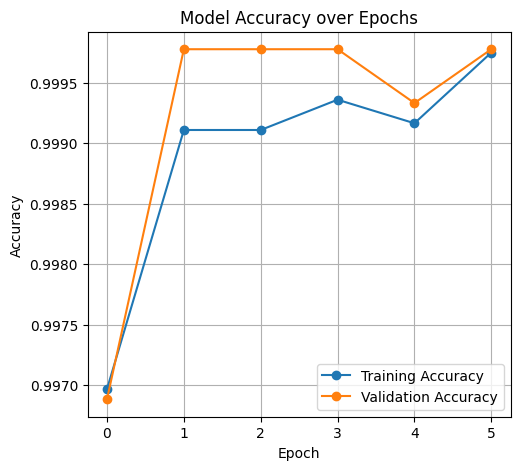

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ===============================
# 1. Plot Accuracy and Loss
# ===============================

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)



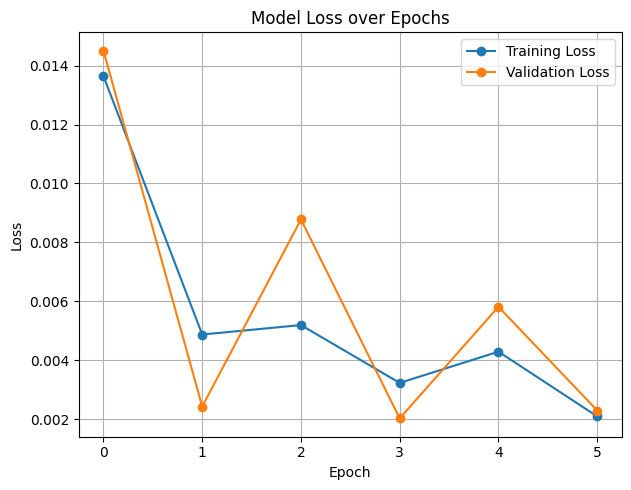

In [29]:
# Loss plot
plt.figure(figsize=(12,5))
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


<Figure size 500x500 with 0 Axes>

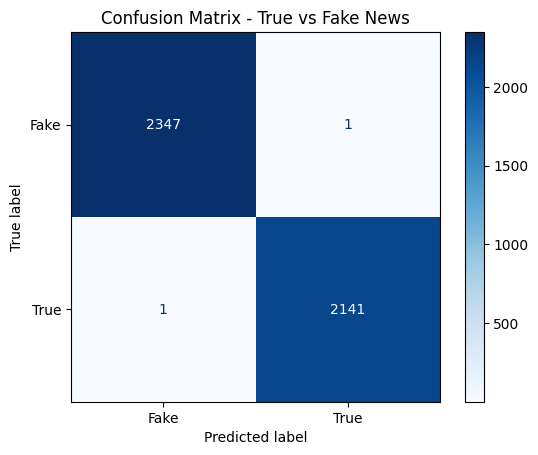

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# y_test = true labels
# predicted_labels = model predictions (already computed earlier)

cm = confusion_matrix(y_test, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'True'])

plt.figure(figsize=(5,5))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - True vs Fake News")
plt.show()


In [33]:
from sklearn.metrics import classification_report
import pandas as pd

# y_test  → true labels
# predicted_labels → model predictions (e.g., tf.argmax(predictions.logits, axis=1).numpy())

# Get detailed metrics as a dict
report = classification_report(y_test, predicted_labels, output_dict=True)

# Convert to a DataFrame
df_report = pd.DataFrame(report).transpose()

# Round and format neatly
df_report = df_report.round(4)
print(df_report)

# (Optional) Save to CSV or display nicely
df_report.to_csv("classification_report.csv", index=True)


              precision  recall  f1-score    support
0                0.9996  0.9996    0.9996  2348.0000
1                0.9995  0.9995    0.9995  2142.0000
accuracy         0.9996  0.9996    0.9996     0.9996
macro avg        0.9996  0.9996    0.9996  4490.0000
weighted avg     0.9996  0.9996    0.9996  4490.0000


In [30]:
# ===============================
# Accuracy on Training Data
# ===============================
train_loss, train_acc = model.evaluate(train_dataset)
print(f"Training Accuracy: {train_acc * 100:.2f}%")
print(f"Training Loss: {train_loss:.4f}")

# ===============================
# Accuracy on Test Data
# ===============================
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


2245/2245 [==============================] - 168s 75ms/step - loss: 5.4844e-04 - accuracy: 0.9999
Training Accuracy: 99.99%
Training Loss: 0.0005
281/281 [==============================] - 20s 73ms/step - loss: 0.0022 - accuracy: 0.9996
Test Accuracy: 99.96%
Test Loss: 0.0022


In [32]:
val_loss, val_acc = model.evaluate(val_dataset)
print(f"Validation Accuracy: {val_acc * 100:.2f}%")
print(f"Validation Loss: {val_loss:.4f}")


281/281 [==============================] - 21s 73ms/step - loss: 0.0020 - accuracy: 0.9998
Validation Accuracy: 99.98%
Validation Loss: 0.0020
